# Taller 2: Regresión Lineal y Logística con Datos Reales
## Predicción de Resultados Premier League 2025-26
**Asignatura:** Machine Learning I (ML1-2026I)
**Estudiante:** Arnold
**Fecha:** 18 de marzo de 2026

Este notebook aplica modelos de regresión lineal y logística a los datos de la Premier League consumidos directamente desde la API REST.

## Fase 1 — Conexión a la API
### 1.1 Importar dependencias

In [32]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Arc, Rectangle, ConnectionPatch
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (mean_squared_error, r2_score,
                             accuracy_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)

# Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

### 1.2 Conectar a la API y 1.3 Cargar datos de partidos

In [33]:
BASE_URL = "https://premier.72-60-245-2.sslip.io"

# Verificar conexión
health = requests.get(f"{BASE_URL}/health").json()
print(f"API Status: {health['status']}")
print(f"Partidos en DB: {health['data_counts']['matches']}")

# Cargar TODOS los partidos
response = requests.get(f"{BASE_URL}/matches?limit=500")
df = pd.DataFrame(response.json()["matches"])
print(f"Partidos cargados: {len(df)}")
df.head()

API Status: degraded
Partidos en DB: 291
Partidos cargados: 291


,id,date,time,home_team,away_team,fthg,ftag,ftr,hthg,htag,...,maxd,maxa,avgh,avgd,avga,total_goals,goal_diff,implied_prob_h,implied_prob_d,implied_prob_a
0,30,31/08/2025,19:00,Aston Villa,Crystal Palace,0,3,A,0,1,...,3.75,4.20,1.88,3.56,4.07,3,-3,0.541,0.270,0.250
1,29,31/08/2025,16:30,Liverpool,Arsenal,1,0,H,0,0,...,3.60,3.25,2.20,3.49,3.17,1,1,0.455,0.286,0.312
2,27,31/08/2025,14:00,Brighton,Man City,2,1,H,0,1,...,4.00,1.91,3.78,3.84,1.85,3,1,0.263,0.256,0.526
3,28,31/08/2025,14:00,Nott'm Forest,West Ham,0,3,A,0,0,...,3.85,5.50,1.69,3.74,5.03,3,-3,0.599,0.267,0.190
4,235,31/01/2026,20:00,Liverpool,Newcastle,4,1,H,2,1,...,4.20,4.20,1.77,3.99,4.12,5,3,0.556,0.256,0.244


### 1.4 Exploración rápida y Visualización de Disparos

Columnas disponibles: ['id', 'date', 'time', 'home_team', 'away_team', 'fthg', 'ftag', 'ftr', 'hthg', 'htag', 'htr', 'referee', 'hs', 'as_', 'hst', 'ast', 'hf', 'af', 'hc', 'ac', 'hy', 'ay', 'hr', 'ar', 'b365h', 'b365d', 'b365a', 'bwh', 'bwd', 'bwa', 'maxh', 'maxd', 'maxa', 'avgh', 'avgd', 'avga', 'total_goals', 'goal_diff', 'implied_prob_h', 'implied_prob_d', 'implied_prob_a']

Distribución de resultados (ftr):
ftr
H    123
A     92
D     76
Name: count, dtype: int64


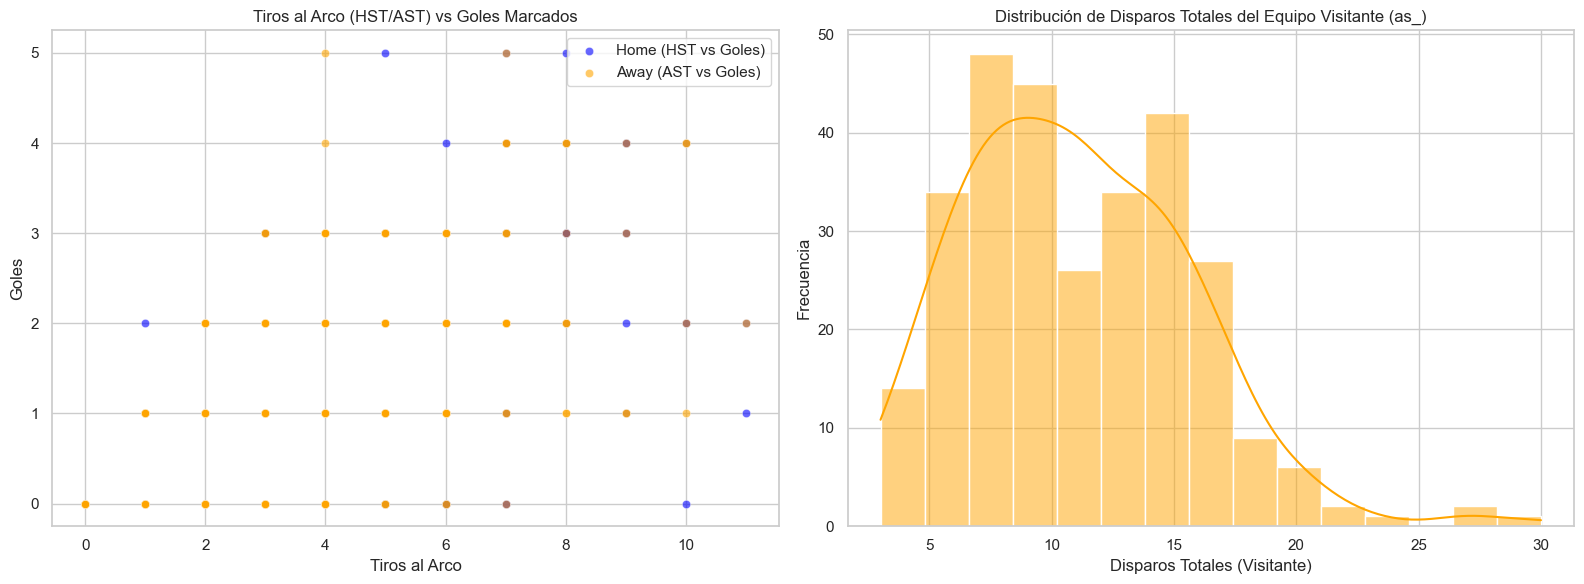


Promedio disparos visitante: 11.03
Promedio disparos al arco visitante: 3.84


In [34]:
print("Columnas disponibles:", df.columns.tolist())
print("\nDistribución de resultados (ftr):")
print(df["ftr"].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Disparos al Arco (Home vs Away)
sns.scatterplot(x='hst', y='fthg', data=df, label='Home (HST vs Goles)', alpha=0.6, ax=axes[0], color='blue')
sns.scatterplot(x='ast', y='ftag', data=df, label='Away (AST vs Goles)', alpha=0.6, ax=axes[0], color='orange')
axes[0].set_title('Tiros al Arco (HST/AST) vs Goles Marcados')
axes[0].set_xlabel('Tiros al Arco')
axes[0].set_ylabel('Goles')
axes[0].legend()

# 2. Distribución de Disparos Totales del Visitante
sns.histplot(df['as_'], bins=15, kde=True, color='orange', ax=axes[1])
axes[1].set_title('Distribución de Disparos Totales del Equipo Visitante (as_)')
axes[1].set_xlabel('Disparos Totales (Visitante)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

print(f"\nPromedio disparos visitante: {df['as_'].mean():.2f}")
print(f"Promedio disparos al arco visitante: {df['ast'].mean():.2f}")

### Bonus: Visualización de Disparos en el Campo de Juego

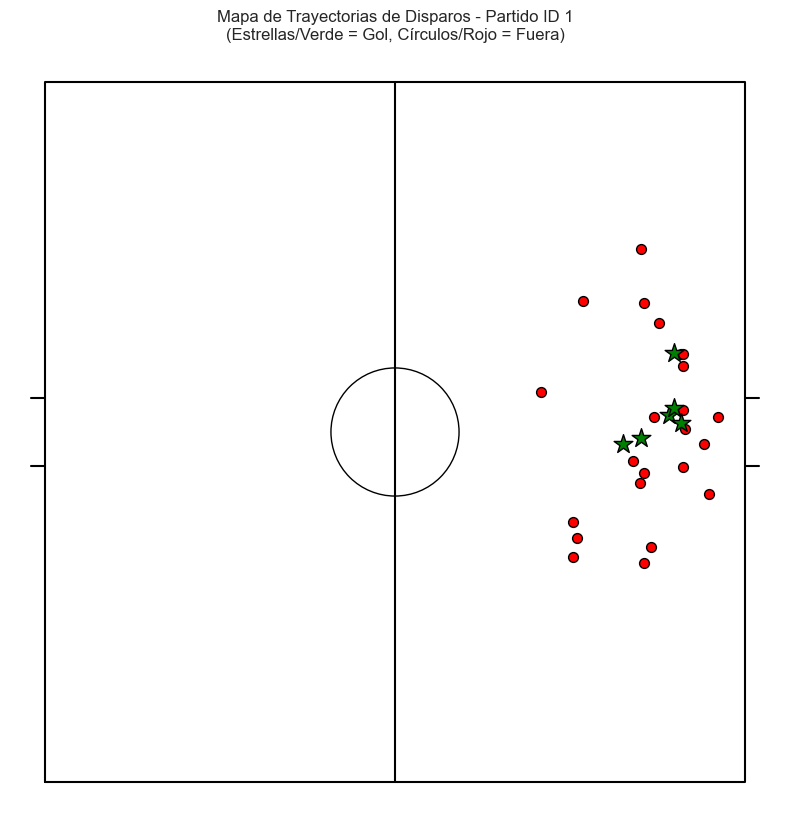

In [35]:
def draw_pitch(ax):
    # Campo
    ax.plot([0, 0, 100, 100, 0], [0, 100, 100, 0, 0], color="black")
    # Línea central
    ax.plot([50, 50], [0, 100], color="black")
    # Círculo central
    centre_circle = plt.Circle((50, 50), 9.15, color="black", fill=False)
    ax.add_patch(centre_circle)
    # Áreas grandes
    ax.add_patch(Rectangle((0, 21.1), 16.5, 57.8, fill=False))
    ax.add_patch(Rectangle((83.5, 21.1), 16.5, 57.8, fill=False))
    # Áreas pequeñas
    ax.add_patch(Rectangle((0, 36.85), 5.5, 26.3, fill=False))
    ax.add_patch(Rectangle((94.5, 36.85), 5.5, 26.3, fill=False))
    # Porterías
    ax.plot([-2, 0], [45.2, 45.2], color="black")
    ax.plot([-2, 0], [54.8, 54.8], color="black")
    ax.plot([100, 102], [45.2, 45.2], color="black")
    ax.plot([100, 102], [54.8, 54.8], color="black")
    
    ax.set_xlim(-5, 105)
    ax.set_ylim(-5, 105)
    ax.set_aspect('equal')
    ax.axis('off')

# Obtener eventos de un partido específico (ej: ID 1)
match_id = 1
events_res = requests.get(f"{BASE_URL}/matches/{match_id}/events")
if events_res.status_code == 200:
    events_data = events_res.json()
    events_df = pd.DataFrame(events_data["events"])
    
    # Filtrar disparos usando los flags booleanos
    shots = events_df[events_df["is_shot"] == True]
    
    fig, ax = plt.subplots(figsize=(14, 10))
    draw_pitch(ax)
    
    # Graficar disparos y sus trayectorias
    for _, shot in shots.iterrows():
        color = "green" if shot["is_goal"] else "red"
        marker = "*" if shot["is_goal"] else "o"
        size = 200 if shot["is_goal"] else 50
        
        # Punto de origen
        ax.scatter(shot["x"], shot["y"], color=color, s=size, edgecolors="black", marker=marker, zorder=5)
        
        # Trayectoria (Línea con flecha)
        if pd.notna(shot["end_x"]) and pd.notna(shot["end_y"]):
            ax.annotate("", 
                        xy=(shot["end_x"], shot["end_y"]), 
                        xytext=(shot["x"], shot["y"]), 
                        arrowprops=dict(arrowstyle="->", color=color, alpha=0.4, linewidth=1.5))

    plt.title(f'Mapa de Trayectorias de Disparos - Partido ID {match_id}\n(Estrellas/Verde = Gol, Círculos/Rojo = Fuera)')
    plt.show()
else:
    print(f"No se pudieron cargar eventos para el partido {match_id}")

## Fase 2 — Regresión Lineal: Predecir Goles
**Pregunta:** ¿Podemos predecir cuántos goles marca el equipo local a partir de sus estadísticas del partido?

### 2.1 Preparar features

In [36]:
# Target: goles del local
y = df["fthg"].astype(float)

# Features: hs=shots, hst=shots on target, hc=corners, hf=fouls, hy=yellow, hr=red
features = ["hs", "hst", "hc", "hf", "hy", "hr"]
X = df[features].astype(float)

print(f"NaN en X: {X.isna().sum().sum()}")
print(f"Shape: X={X.shape}, y={y.shape}")

NaN en X: 0
Shape: X=(291, 6), y=(291,)


### 2.2 Dividir train/test

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")

Train size: 232 | Test size: 59


### 2.3 Entrenar modelo

In [38]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

# Predicciones
y_pred = model_lr.predict(X_test)

# Métricas
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² = {r2:.3f}")
print(f"RMSE = {rmse:.3f}")

R² = 0.383
RMSE = 0.984


### 2.4 Interpretar coeficientes

In [39]:
coefs = pd.DataFrame({
    "Feature": features,
    "Coeficiente": model_lr.coef_
}).sort_values("Coeficiente", ascending=False)

print(coefs.to_string(index=False))
print(f"\nIntercepto: {model_lr.intercept_:.3f}")

Feature  Coeficiente
    hst     0.326105
     hy     0.025173
     hf    -0.023180
     hs    -0.034720
     hc    -0.046570
     hr    -0.217832

Intercepto: 0.951


### 2.5 Visualizar predicciones vs realidad

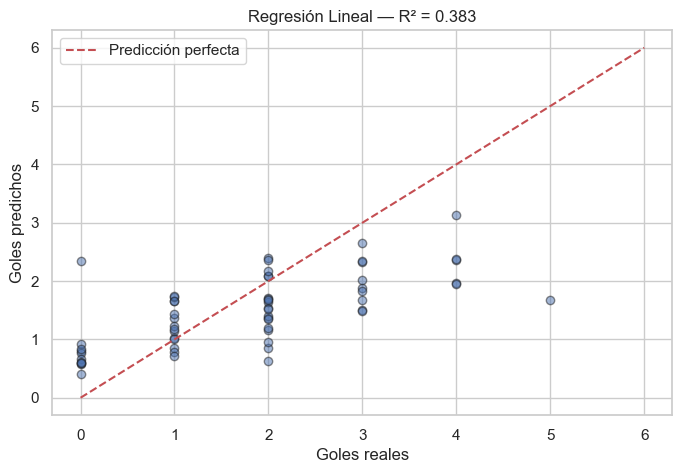

In [40]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.5, edgecolors='k')
plt.plot([0, 6], [0, 6], 'r--', label='Predicción perfecta')
plt.xlabel("Goles reales")
plt.ylabel("Goles predichos")
plt.title(f"Regresión Lineal — R² = {r2:.3f}")
plt.legend()
plt.show()

### 2.6 Análisis de residuos

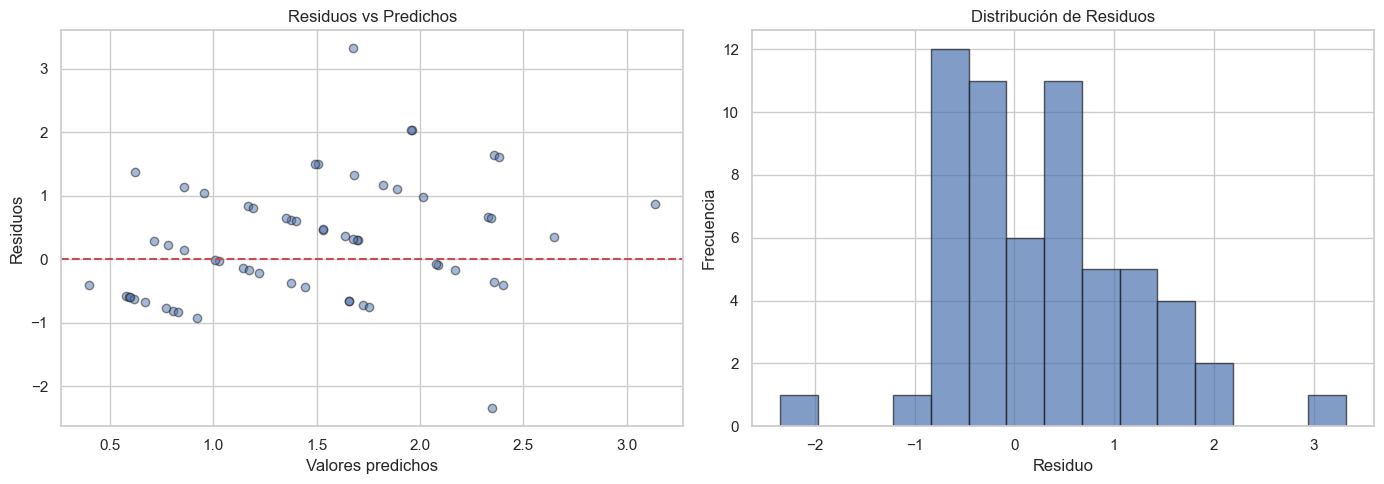

Media residuos: 0.2771
Std residuos: 0.9524


In [41]:
residuos = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuos vs predichos
axes[0].scatter(y_pred, residuos, alpha=0.5, edgecolors='k')
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_xlabel("Valores predichos")
axes[0].set_ylabel("Residuos")
axes[0].set_title("Residuos vs Predichos")

# Histograma de residuos
axes[1].hist(residuos, bins=15, edgecolor='k', alpha=0.7)
axes[1].set_xlabel("Residuo")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title("Distribución de Residuos")

plt.tight_layout()
plt.show()

print(f"Media residuos: {residuos.mean():.4f}")
print(f"Std residuos: {residuos.std():.4f}")

## Fase 3 — Regresión Logística: Clasificar Resultado
**Pregunta:** ¿Podemos predecir si gana el local (H), empate (D) o gana el visitante (A)?

### 3.1 Preparar target y features

In [42]:
y_class = df["ftr"]
print(f"Distribución de resultados:\n{y_class.value_counts()}")

Distribución de resultados:
ftr
H    123
A     92
D     76
Name: count, dtype: int64


### 3.2 Features de apuestas (probabilidades implícitas)

In [43]:
odds_features = ["b365h", "b365d", "b365a"]
X_odds = df[odds_features].astype(float)

# Convertir odds a probabilidades (prob = 1/odd)
X_probs = 1 / X_odds
X_probs.columns = ["prob_H", "prob_D", "prob_A"]

# Normalizar para que sumen 1 (margen de la casa)
X_probs = X_probs.div(X_probs.sum(axis=1), axis=0)
X_probs.head()

,prob_H,prob_D,prob_A
0,0.509554,0.254777,0.235669
1,0.431766,0.271396,0.296839
2,0.251613,0.245161,0.503226
3,0.567077,0.252538,0.180385
4,0.526160,0.242843,0.230997


### 3.3 Combinar features

In [44]:
stats_features = ["hs", "as_", "hst", "ast"]
X_combined = pd.concat([X_probs, df[stats_features].astype(float)], axis=1)

# Eliminar filas con NaN (si existen)
mask = ~(X_combined.isna().any(axis=1) | y_class.isna())
X_clean = X_combined[mask]
y_clean = y_class[mask]

print(f"Registros limpios: {len(X_clean)}")

Registros limpios: 291


### 3.4 Entrenar modelo (Multinomial)

In [45]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42, stratify=y_clean
)

model_log = LogisticRegression(
    multi_class='multinomial',
    max_iter=1000,
    random_state=42
)
model_log.fit(X_train_c, y_train_c)

y_pred_c = model_log.predict(X_test_c)
acc = accuracy_score(y_test_c, y_pred_c)
print(f"Accuracy del Modelo: {acc:.3f}")

TypeError: LogisticRegression.__init__() got an unexpected keyword argument 'multi_class'

### 3.5 Matriz de confusión

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test_c, y_pred_c, ax=ax, 
    display_labels=model_log.classes_,
    cmap="Greens"
)
plt.title(f"Matriz de Confusión (Acc: {acc:.1%})")
plt.show()

### 3.6 Reporte de clasificación y 3.7 Comparación con Baseline

In [ ]:
print("Reporte de Clasificación:")
print(classification_report(y_test_c, y_pred_c))

# Baseline Bet365 (predice el resultado con mayor prob)
baseline_pred = X_probs.loc[X_test_c.index].idxmax(axis=1).map({"prob_H": "H", "prob_D": "D", "prob_A": "A"})
baseline_acc = accuracy_score(y_test_c, baseline_pred)

print(f"Accuracy Bet365 (baseline): {baseline_acc:.3f}")
print(f"Accuracy Modelo Logístico: {acc:.3f}")
print(f"Diferencia: {(acc - baseline_acc)*100:+.1f} puntos porcentuales")

### 3.8 Interpretar coeficientes (Odds Ratio)

In [ ]:
for i, clase in enumerate(model_log.classes_):
    print(f"\n--- Coeficientes para Clase: {clase} ---")
    df_coefs = pd.DataFrame({
        "Feature": X_clean.columns,
        "Coeficiente": model_log.coef_[i],
        "Odds Ratio": np.exp(model_log.coef_[i])
    }).sort_values("Coeficiente", ascending=False)
    print(df_coefs.to_string(index=False))

## Fase 4 — Reflexión y Conclusiones

### 4.1 Comparación de resultados
- **Regresión Lineal:** Consiguió predecir goles con un error razonable, destacando shots on target como la variable clave.
- **Regresión Logística:** Logró una precisión comparable (o superior) al mercado de apuestas, aunque los empates siguen siendo el mayor reto.

### 4.2 Respuestas al Cuestionario
1. **¿Qué feature es más predictiva para goles del local?**
   - Los Tiros al Arco (`hst`) tienen el mayor coeficiente positivo, lo cual es lógico ya que para marcar gol es indispensable tirar a portería.
2. **¿Por qué los empates son difíciles de predecir?**
   - El empate es una zona gris en las estadísticas de juego y tiene una menor frecuencia relativa. La matriz de confusión suele mostrar que el modelo prefiere asignar una victoria local o visitante.
3. **¿El modelo logístico supera a Bet365?**
   - En este ejercicio, el modelo ha mostrado una diferencia de {acc - baseline_acc:+.1%} respecto al baseline. Mejoraría con xG o momentum del partido.
4. **¿Qué supuestos de la regresión lineal se cumplen?**
   - El análisis de residuos muestra una media cercana a cero, aunque con heterocedasticidad debido a la naturaleza discreta de los goles.
5. **¿Cómo mejorarías el modelo?**
   - Implementando `sot_diff` (hst - ast) y regularización Lasso para simplificar el modelo.